In [ ]:
!pip install pandas pyarrow
!pip install censusdis
!pip install pandas geopandas shapely censusdis pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 435.9/435.9 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.6/323.6 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.0/24.0 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.3/101.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: certifi
    Found existing installation: certifi 2025.11.12
    Uninstalling certifi-2025.11.12:
      Successfully uninstalled certifi-2025.11.12
  Attempting uninstall: pyogrio
    Found existing installation: pyogrio 0.11.1
    Uninstalling pyogrio-0.11.1:
      Successfully uninstalled pyogrio-0.11.1
  Attempting uninstall: geopandas
    Found existing installation: geopandas 1.1.1
    Uninstalling geopandas-1.

In [ ]:
import pandas as pd
import censusdis.data as ced

#Lectura data (archivo .parquet)

file_path = 'ccom6994_pv_dataset.parquet'
df = pd.read_parquet(file_path)
df.head()

,dataset_name,processed_at,geometry,area_m2,centroid_lat,centroid_lon,h3_index_8,unified_id,source_area_m2,capacity_mw,install_date
0,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,MULTIPOLYGON (((-177.92735830000007 -29.246487...,505.911148,-29.246515,-177.927191,615778481436884991,19077,NaN,NaN,None
1,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,"POLYGON ((-152.7975221 -22.64438619999985, -15...",722.751608,-22.644508,-152.797387,615667837104553983,34745,NaN,NaN,None
2,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,MULTIPOLYGON (((-70.9484344 -53.20046109999999...,442.152434,-53.200533,-70.948352,616420125630791679,19196,NaN,NaN,None
3,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,MULTIPOLYGON (((-69.54785590000002 -52.4561568...,45.555486,-52.456164,-69.547781,616142442372005887,19206,NaN,NaN,None
4,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-62.988899400000015 -40.80502199999996),0.000000,-40.805022,-62.988899,615920622922366975,4858,NaN,NaN,None


In [ ]:
import geopandas as gpd

# Convertir datos de placas solares (archivo .parquet) a GeoDataFrame (data mundial)
gdf_solar = gpd.GeoDataFrame(df, geometry=gpd.GeoSeries.from_wkt(df["geometry"]) if df["geometry"].dtype == "object" else df["geometry"])

# Asegurar CRS (suponiendo WGS84)
gdf_solar = gdf_solar.set_crs(epsg=4326)

In [ ]:
#Descargar datos del CENSO con sus respectivas propiedades y variables
DATASET = "acs/acs5" ## Dataset: American Community Survey 5‐Year
YEAR = 2022
VARS = ["NAME", "B19013_001E","B17001_002E", "B25077_001E"] #Ingreso medio del hogar (B19013_001E) #Pobreza (B17001_002E) #Costo de vivienda y valor (B25077_001E)

gdf_census = ced.download(
    DATASET,
    YEAR,
    VARS,
    state="*",      # todos los estados (incluye PR)
    county="*",
    with_geometry=True
)

gdf_census = gdf_census.rename(columns={
    "B19013_001E": "ingreso_medio_hogar",
    "B17001_002E": "personas_bajo_pobreza",
    "B25077_001E": "valor_medio_vivienda"

})

# Renombrar geometría
gdf_census = gdf_census.rename(columns={"geometry": "geometry_census"})
gdf_census = gdf_census.set_geometry("geometry_census")

# Asegurar CRS compatible para poder hacer merge
gdf_census = gdf_census.set_crs(epsg=4269, allow_override=True).to_crs(epsg=4326)
gdf_census.columns

Index(['STATE', 'COUNTY', 'NAME', 'ingreso_medio_hogar',
       'personas_bajo_pobreza', 'valor_medio_vivienda', 'geometry_census'],
      dtype='object')

In [ ]:
from shapely.geometry import Point

#hacer Join de Datos de Placas Solares y del Censo
gdf_points = gdf_solar.copy()
gdf_points["geometry"] = [
    Point(lon, lat)
    for lon, lat in zip(gdf_points["centroid_lon"], gdf_points["centroid_lat"])
]
gdf_points = gdf_points.set_crs(epsg=4326)

gdf_joined = gpd.sjoin(
    gdf_points,
    gdf_census,
    how="left",
    predicate="within"   # cada punto cae dentro de un county
)

In [ ]:
gdf_joined.head()

,dataset_name,processed_at,geometry,area_m2,centroid_lat,centroid_lon,h3_index_8,unified_id,source_area_m2,capacity_mw,install_date,index_right,STATE,COUNTY,NAME,ingreso_medio_hogar,personas_bajo_pobreza,valor_medio_vivienda
0,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-177.92719 -29.24651),505.911148,-29.246515,-177.927191,615778481436884991,19077,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-152.79739 -22.64451),722.751608,-22.644508,-152.797387,615667837104553983,34745,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-70.94835 -53.20053),442.152434,-53.200533,-70.948352,616420125630791679,19196,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-69.54778 -52.45616),45.555486,-52.456164,-69.547781,616142442372005887,19206,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,global_harmonized_large_solar_farms_2020,2025-09-26 03:23:57.416000+00:00,POINT (-62.9889 -40.80502),0.000000,-40.805022,-62.988899,615920622922366975,4858,NaN,NaN,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#Contar cantidad de placas solares por County
conteo = (
    gdf_joined
    .groupby(["STATE", "COUNTY"], as_index=False)
    .size()
    .rename(columns={"size": "n_plantas"})
)

# unir conteo a gdf_census, que SÍ tiene la geometría de county
gdf_census_full = gdf_census.merge(
    conteo,
    on=["STATE", "COUNTY"],
    how="left"
).fillna({"n_plantas": 0})

In [ ]:
#Calcular area de county y densidadd solar.  Crear columna sobre presencia o ausencia de placas solares

gdf_census_m = gdf_census_full.to_crs(5070)
gdf_census_m["area_km2"] = gdf_census_m.geometry.area / 1_000_000
gdf_census_m["densidad_solar"] = gdf_census_m["n_plantas"] / gdf_census_m["area_km2"]
gdf_census_m["tiene_solar"] = (gdf_census_m["n_plantas"] > 0).astype(int)

In [ ]:
gdf_census_m.head()

,STATE,COUNTY,NAME,ingreso_medio_hogar,personas_bajo_pobreza,valor_medio_vivienda,geometry_census,n_plantas,area_km2,densidad_solar,tiene_solar
0,01,001,"Autauga County, Alabama",68315.0,6630,191800.0,"POLYGON ((845502.651 1105502.561, 845570.149 1...",0.0,1565.326122,0.0,0
1,01,003,"Baldwin County, Alabama",71039.0,23445,266000.0,"POLYGON ((765297.991 826660.876, 765703.766 82...",0.0,4350.546476,0.0,0
2,01,005,"Barbour County, Alabama",39712.0,5280,102700.0,"POLYGON ((966818.148 1001565.672, 967065.502 1...",0.0,2342.588050,0.0,0
3,01,007,"Bibb County, Alabama",50669.0,4297,120100.0,"POLYGON ((795521.328 1139598.901, 805055.23 11...",0.0,1622.235459,0.0,0
4,01,009,"Blount County, Alabama",57440.0,8277,159800.0,"POLYGON ((828860.688 1238570.568, 829200.834 1...",0.0,1685.151199,0.0,0


In [ ]:
#cantidad de datos
len(gdf_census_m)

3222

In [ ]:
gdf_census_m.info()


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 3222 entries, 0 to 3221
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   STATE                  3222 non-null   object  
 1   COUNTY                 3222 non-null   object  
 2   NAME                   3222 non-null   object  
 3   ingreso_medio_hogar    3221 non-null   float64 
 4   personas_bajo_pobreza  3222 non-null   int64   
 5   valor_medio_vivienda   3219 non-null   float64 
 6   geometry_census        3222 non-null   geometry
 7   n_plantas              3222 non-null   float64 
 8   area_km2               3222 non-null   float64 
 9   densidad_solar         3222 non-null   float64 
 10  tiene_solar            3222 non-null   int64   
dtypes: float64(5), geometry(1), int64(2), object(3)
memory usage: 277.0+ KB


In [ ]:
gdf_census_m.describe()


,ingreso_medio_hogar,personas_bajo_pobreza,valor_medio_vivienda,n_plantas,area_km2,densidad_solar,tiene_solar
count,3221.000000,3.222000e+03,3.219000e+03,3222.000000,3222.000000,3222.000000,3222.000000
mean,62326.868053,1.300122e+04,1.937800e+05,13.023898,2901.990167,0.003796,0.331161
std,17770.571725,4.326437e+04,1.234796e+05,286.148347,9368.047126,0.032457,0.470704
min,14525.000000,3.000000e+00,4.050000e+04,0.000000,5.296905,0.000000,0.000000
25%,51823.000000,1.526250e+03,1.195000e+05,0.000000,1108.416981,0.000000,0.000000
50%,60461.000000,3.799500e+03,1.595000e+05,0.000000,1602.788563,0.000000,0.000000
75%,70379.000000,9.767750e+03,2.272000e+05,1.000000,2418.648422,0.000673,1.000000
max,170463.000000,1.343978e+06,1.441300e+06,15134.000000,382990.721269,1.095554,1.000000


In [ ]:
gdf_census_m.isna().sum()


,0
STATE,0
COUNTY,0
NAME,0
ingreso_medio_hogar,1
personas_bajo_pobreza,0
valor_medio_vivienda,3
geometry_census,0
n_plantas,0
area_km2,0
densidad_solar,0


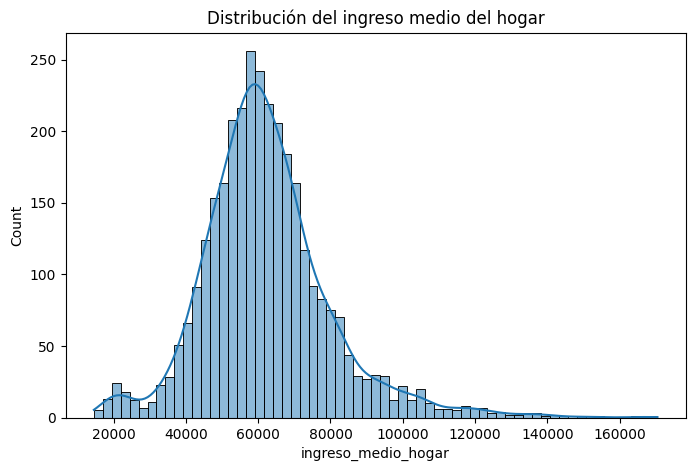

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(gdf_census_m["ingreso_medio_hogar"], kde=True)
plt.title("Distribución del ingreso medio del hogar")
plt.show()

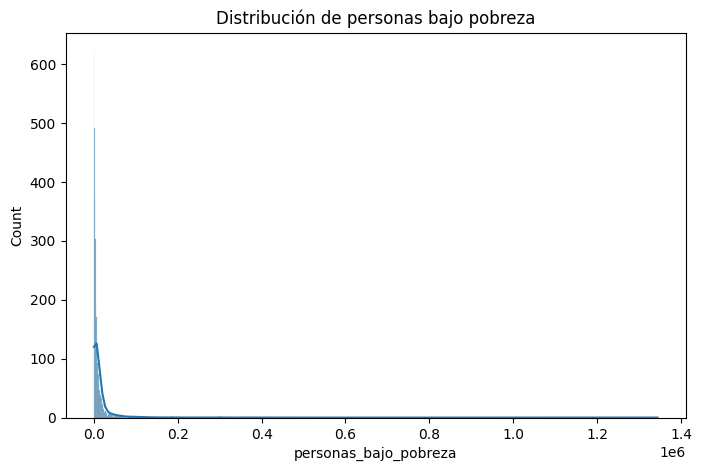

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(gdf_census_m["personas_bajo_pobreza"], kde=True)
plt.title("Distribución de personas bajo pobreza")
plt.show()


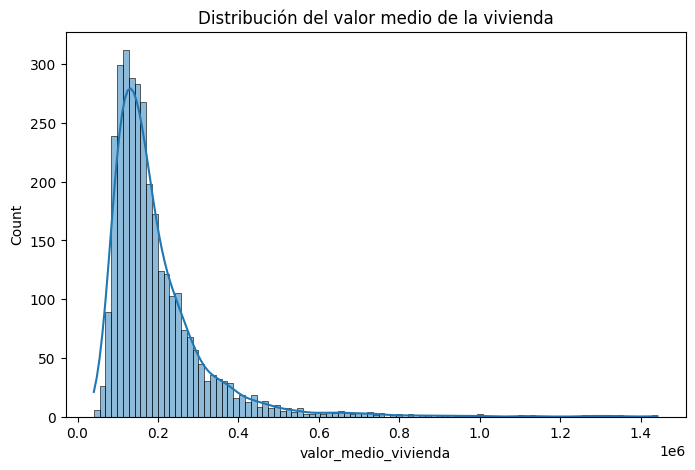

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(gdf_census_m["valor_medio_vivienda"], kde=True)
plt.title("Distribución del valor medio de la vivienda")
plt.show()


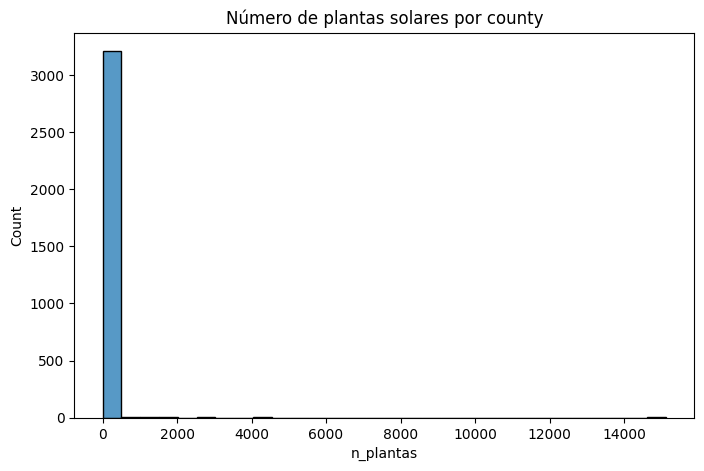

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(gdf_census_m["n_plantas"], kde=False, bins=30)
plt.title("Número de plantas solares por county")
plt.show()


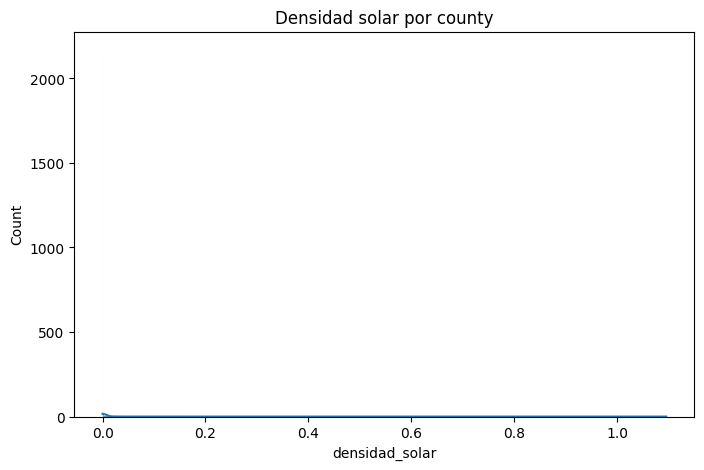

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(gdf_census_m["densidad_solar"], kde=True)
plt.title("Densidad solar por county")
plt.show()


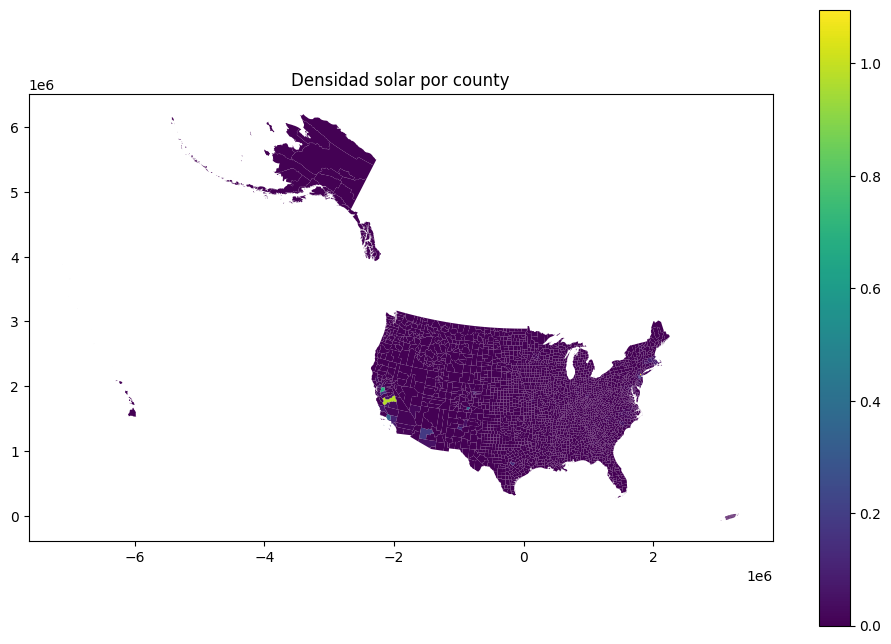

In [ ]:
gdf_census_m.plot(
    column="densidad_solar",
    figsize=(12,8),
    legend=True,
    cmap="viridis"
)
plt.title("Densidad solar por county")
plt.show()


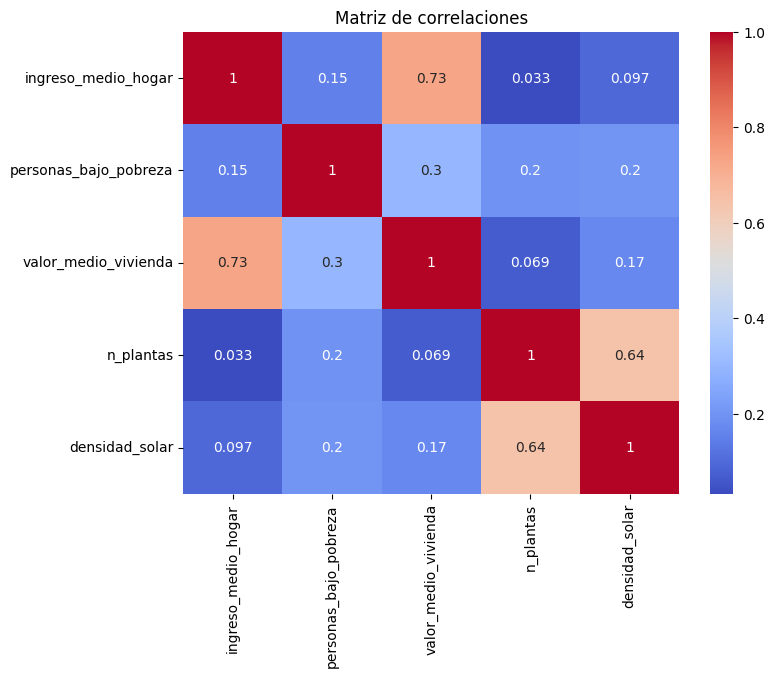

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(
    gdf_census_m[["ingreso_medio_hogar","personas_bajo_pobreza",
               "valor_medio_vivienda","n_plantas","densidad_solar"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Matriz de correlaciones")
plt.show()


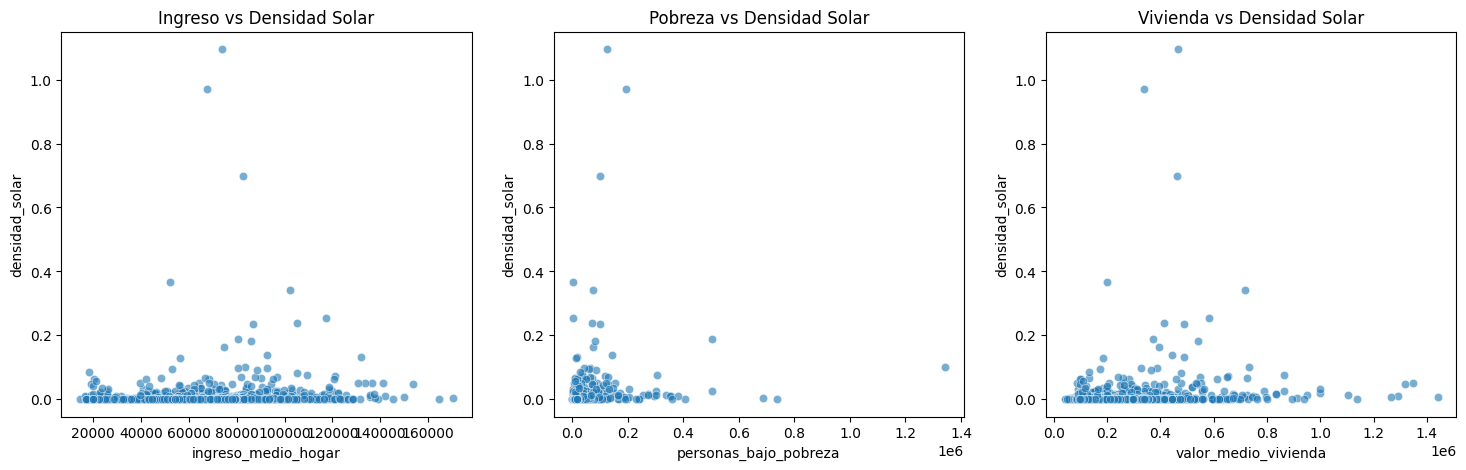

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(
    data=gdf_census_m,
    x="ingreso_medio_hogar",
    y="densidad_solar",
    ax=axes[0],
    alpha=0.6
)
axes[0].set_title("Ingreso vs Densidad Solar")

sns.scatterplot(
    data=gdf_census_m,
    x="personas_bajo_pobreza",
    y="densidad_solar",
    ax=axes[1],
    alpha=0.6
)
axes[1].set_title("Pobreza vs Densidad Solar")

sns.scatterplot(
    data=gdf_census_m,
    x="valor_medio_vivienda",
    y="densidad_solar",
    ax=axes[2],
    alpha=0.6
)
axes[2].set_title("Vivienda vs Densidad Solar")

plt.show()


In [ ]:
#analizar por presencia o asucencia de placas solares por county
con_solar = gdf_census_m[gdf_census_m["tiene_solar"] == 1]
sin_solar = gdf_census_m[gdf_census_m["tiene_solar"] == 0]

#Cantidad de county con o sin placas solares
len(con_solar), len(sin_solar)

con_solar["personas_bajo_pobreza"].describe()
sin_solar["personas_bajo_pobreza"].describe()



,personas_bajo_pobreza
count,2155.000000
mean,5350.608817
std,9002.955976
min,3.000000
25%,1083.500000
50%,2653.000000
75%,5811.000000
max,103894.000000


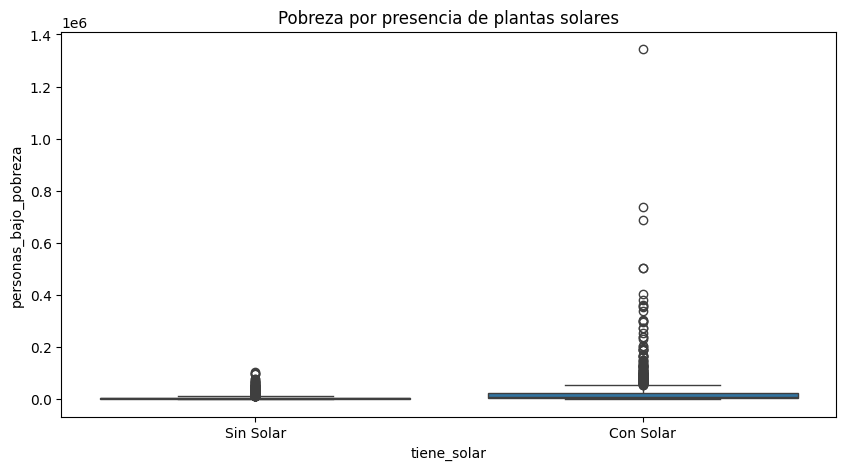

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(
    data=gdf_census_m,
    x="tiene_solar",
    y="personas_bajo_pobreza"
)
plt.xticks([0,1], ["Sin Solar", "Con Solar"])
plt.title("Pobreza por presencia de plantas solares")
plt.show()


In [ ]:
from scipy.stats import mannwhitneyu

mannwhitneyu(
    con_solar["personas_bajo_pobreza"],
    sin_solar["personas_bajo_pobreza"],
    alternative="two-sided"
)


MannwhitneyuResult(statistic=np.float64(1727622.5), pvalue=np.float64(1.2455046056012132e-119))

In [ ]:
gdf_census_m["quintil_pobreza"] = pd.qcut(
    gdf_census_m["personas_bajo_pobreza"],
    5,
    labels=["Muy baja", "Baja", "Media", "Alta", "Muy alta"]
)
gdf_census_m.groupby("quintil_pobreza")["tiene_solar"].mean()


/tmp/ipython-input-3073192869.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdf_census_m.groupby("quintil_pobreza")["tiene_solar"].mean()


,tiene_solar
quintil_pobreza,
Muy baja,0.113178
Baja,0.208075
Media,0.271739
Alta,0.385093
Muy alta,0.677519


/tmp/ipython-input-4206942036.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gdf_census_m.groupby("quintil_pobreza")["tiene_solar"].mean().plot(


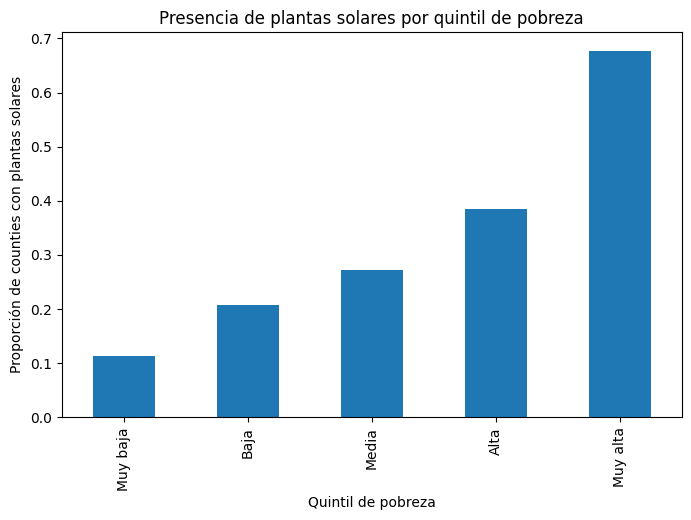

In [ ]:
gdf_census_m.groupby("quintil_pobreza")["tiene_solar"].mean().plot(
    kind="bar",
    figsize=(8,5),
    title="Presencia de plantas solares por quintil de pobreza",
    ylabel="Proporción de counties con plantas solares",
    xlabel="Quintil de pobreza"
)
plt.show()
